# **Day 68: NLP - Text Representation and Word Embeddings**
*Module 11 - Advanced Deep Learning*

Text is everywhere in science and society: field notes, disaster reports, news, social media during floods, scientific abstracts (literature mining for our review paper!). Models need text as **numbers**. Today we go from counting words to learning **dense embeddings** where meaning becomes geometry.

> Computers need numbers, so text must be converted into vectors. From simple word counts to embeddings, the goal is that words with similar meanings get similar vectors.
>
> *Example:* In a good embedding, "flood" and "inundation" are close together, while "flood" and "drought" are far apart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, collections, itertools
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(68); rng = np.random.default_rng(68)

## **1. A Corpus: Short Disaster and Agriculture Reports**
We generate a corpus of short reports about floods, droughts, cyclones, landslides and crop conditions from templates with synonyms, so that the meaning structure is known (and nothing needs downloading).

In [2]:
topics = {
    "flood": {"subj": ["river", "embankment", "village", "rice field", "road"], "verb": ["flooded", "submerged", "inundated", "overflowed"],
              "extra": ["heavy rain", "monsoon downpour", "water level rose", "dam release", "evacuation started"]},
    "drought": {"subj": ["crop", "pond", "well", "paddy", "soil"], "verb": ["dried", "withered", "failed", "cracked"],
                "extra": ["no rain", "deficit rainfall", "heat wave", "water scarcity", "low groundwater"]},
    "cyclone": {"subj": ["coast", "fishing boat", "tree", "house roof", "power line"], "verb": ["damaged", "uprooted", "blown away", "destroyed"],
                "extra": ["strong wind", "storm surge", "landfall", "gusts", "cyclone warning"]},
    "landslide": {"subj": ["hill road", "slope", "village", "highway", "tea garden"], "verb": ["blocked", "buried", "collapsed", "slid"],
                  "extra": ["debris flow", "steep slope", "cracks appeared", "continuous rain", "mud and rocks"]},
    "good_crop": {"subj": ["crop", "rice field", "wheat", "maize", "orchard"], "verb": ["flourished", "grew well", "thrived", "ripened"],
                  "extra": ["good rain", "timely sowing", "healthy canopy", "high yield expected", "fertiliser applied"]}}
districts = ["Dhanbad", "Bokaro", "Ranchi", "Midnapore", "Puri", "Darjeeling", "Wayanad", "Anantapur", "Kutch", "Nadia"]
def report(topic, r):
    t = topics[topic]
    parts = [f"the {r.choice(t['subj'])} {r.choice(t['verb'])} in {r.choice(districts)}", f"after {r.choice(t['extra'])}"]
    if r.random() < 0.6: parts.append(f"and {r.choice(t['extra'])}")
    if r.random() < 0.3: parts.append(f"officials said the {r.choice(t['subj'])} {r.choice(t['verb'])}")
    return " ".join(parts) + "."
labels = list(topics)
docs, y = [], []
for k, tp in enumerate(labels):
    for _ in range(600):
        docs.append(report(tp, rng)); y.append(k)
y = np.array(y); print(len(docs), "documents | examples:"); [print(" -", docs[i]) for i in [0, 700, 1300, 1900, 2500]];

3000 documents | examples:
 - the village submerged in Darjeeling after evacuation started.
 - the soil failed in Bokaro after water scarcity and deficit rainfall.
 - the power line uprooted in Wayanad after gusts and storm surge.
 - the highway collapsed in Wayanad after mud and rocks.
 - the crop grew well in Nadia after fertiliser applied officials said the wheat thrived.


## **2. Tokenisation, Bag-of-Words and TF-IDF**
- **Tokenise**: split text into tokens (words, sub-words, characters); lowercase; remove punctuation.
- **Bag-of-words**: count each vocabulary word per document (order is lost).
- **TF-IDF**: $\text{tf}(t,d)\times\log\frac{N}{\text{df}(t)}$: frequent-everywhere words ("the", "in") get low weight; distinctive words get high weight.
- **n-grams** keep some order ("heavy rain", "no rain").

In [3]:
def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())
print(tokenize("The river FLOODED in Puri, after heavy rain!"))

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
d_tr, d_te, y_tr, y_te = train_test_split(docs, y, test_size=0.3, stratify=y, random_state=0)
for name, vec in [("bag-of-words unigrams", CountVectorizer()), ("TF-IDF unigrams", TfidfVectorizer()), ("TF-IDF uni+bigrams", TfidfVectorizer(ngram_range=(1, 2)))]:
    clf = make_pipeline(vec, LogisticRegression(max_iter=2000)).fit(d_tr, y_tr)
    print(f"{name:<24} vocabulary {len(clf[0].vocabulary_):>4} | test accuracy {clf.score(d_te, y_te):.3f}")

['the', 'river', 'flooded', 'in', 'puri', 'after', 'heavy', 'rain']


bag-of-words unigrams    vocabulary  109 | test accuracy 1.000
TF-IDF unigrams          vocabulary  109 | test accuracy 1.000
TF-IDF uni+bigrams       vocabulary  399 | test accuracy 1.000


In [4]:
tfidf_clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2)), LogisticRegression(max_iter=2000)).fit(d_tr, y_tr)
vocab = np.array(tfidf_clf[0].get_feature_names_out()); coefs = tfidf_clf[1].coef_
for k, tp in enumerate(labels):
    print(f"{tp:<10}: {', '.join(vocab[np.argsort(coefs[k])[::-1][:6]])}")

flood     : heavy rain, heavy, submerged, inundated, flooded, overflowed
drought   : no rain, no, failed, dried, water scarcity, scarcity
cyclone   : landfall, gusts, destroyed, uprooted, damaged, coast
landslide : slope, continuous rain, continuous, blocked, slid, collapsed
good_crop : good, good rain, thrived, ripened, flourished, canopy


Sparse TF-IDF + logistic regression is fast, interpretable and a strong baseline for document classification. Its weakness: no notion of **similarity between words** ("submerged" and "inundated" are unrelated columns).

## **3. Subword Tokenisation (Byte-Pair Encoding)**
Modern models (BERT, GPT) split text into **subword units** learned from data: frequent words stay whole, rare words are split ("inundated" -> "in", "und", "ated"). No out-of-vocabulary words, a manageable vocabulary. BPE repeatedly merges the most frequent adjacent pair of symbols.

In [5]:
def learn_bpe(words, n_merges=30):
    vocab = collections.Counter(tuple(w) + ("</w>",) for w in words); merges = []
    for _ in range(n_merges):
        pairs = collections.Counter()
        for w, c in vocab.items():
            for a, b in zip(w, w[1:]): pairs[(a, b)] += c
        if not pairs: break
        best = max(pairs, key=pairs.get); merges.append(best); new_vocab = collections.Counter()
        for w, c in vocab.items():
            out, i = [], 0
            while i < len(w):
                if i < len(w) - 1 and (w[i], w[i + 1]) == best: out.append(w[i] + w[i + 1]); i += 2
                else: out.append(w[i]); i += 1
            new_vocab[tuple(out)] += c
        vocab = new_vocab
    return merges, vocab
all_words = list(itertools.chain.from_iterable(tokenize(d) for d in docs))
merges, bpe_vocab = learn_bpe(all_words, 60)
print("first merges:", ["".join(m) for m in merges[:12]])
print("segmentations:", [" ".join(w) for w in list(bpe_vocab)[:8]])

first merges: ['d</w>', 'e</w>', 'in', 'er', 'th', 'an', 'ed</w>', 'er</w>', 'the</w>', 'in</w>', 'ter</w>', 'af']
segmentations: ['the</w>', 'v i l l a g e</w>', 's u b m er g ed</w>', 'in</w>', 'd ar j e el ing</w>', 'after</w>', 'e v a c u at i on </w>', 'st ar ted</w>']


## **4. Word2Vec: Learning Embeddings From Context**
"You shall know a word by the company it keeps" (Firth, 1957). **Skip-gram** (Mikolov et al., 2013): predict context words from a centre word. With **negative sampling**, for each (centre, context) pair we push their vectors' dot product up, and push it down for random "negative" words:
$$\mathcal L = -\log\sigma(\mathbf u_{c}^\top\mathbf v_w) - \sum_{n=1}^{k}\log\sigma(-\mathbf u_{n}^\top\mathbf v_w)$$

In [6]:
sentences = [tokenize(d) for d in docs]
counts = collections.Counter(itertools.chain.from_iterable(sentences))
itos = [w for w, c in counts.most_common()]; stoi = {w: i for i, w in enumerate(itos)}; V = len(itos)
window = 2
pairs = [(stoi[s[i]], stoi[s[j]]) for s in sentences for i in range(len(s)) for j in range(max(0, i - window), min(len(s), i + window + 1)) if i != j]
pairs = torch.tensor(pairs)
freq = np.array([counts[w] for w in itos], float) ** 0.75; neg_dist = torch.tensor(freq / freq.sum(), dtype=torch.float32)   # unigram^0.75
print(f"vocabulary {V} words | {len(pairs):,} (centre, context) training pairs")

class SkipGram(nn.Module):
    def __init__(self, V, d=32):
        super().__init__(); self.inp = nn.Embedding(V, d); self.out = nn.Embedding(V, d)
        nn.init.uniform_(self.inp.weight, -0.5 / d, 0.5 / d); nn.init.zeros_(self.out.weight)
    def forward(self, centre, context, negatives):
        v = self.inp(centre); u_pos = self.out(context); u_neg = self.out(negatives)
        pos = F.logsigmoid((v * u_pos).sum(-1)); neg = F.logsigmoid(-(u_neg @ v.unsqueeze(-1)).squeeze(-1)).sum(-1)
        return -(pos + neg).mean()

sg = SkipGram(V); opt = torch.optim.Adam(sg.parameters(), lr=0.01)
for epoch in range(4):
    perm = torch.randperm(len(pairs)); total = 0
    for s in range(0, len(pairs), 1024):
        b = pairs[perm[s:s + 1024]]; negs = torch.multinomial(neg_dist, len(b) * 5, replacement=True).view(len(b), 5)
        loss = sg(b[:, 0], b[:, 1], negs); opt.zero_grad(); loss.backward(); opt.step(); total += loss.item() * len(b)
    print(f"epoch {epoch}: loss {total / len(pairs):.4f}")
E = F.normalize(sg.inp.weight.detach(), dim=1)

vocabulary 109 words | 124,244 (centre, context) training pairs


epoch 0: loss 2.7161


epoch 1: loss 1.8240


epoch 2: loss 1.6476


epoch 3: loss 1.6215


## **5. Similarity in Embedding Space**

In [7]:
def neighbours(word, k=5):
    sims = E @ E[stoi[word]]; idx = sims.argsort(descending=True)[1:k + 1]
    return [(itos[i], round(sims[i].item(), 2)) for i in idx]
for w in ["flooded", "rain", "slope", "wind", "withered", "puri"]:
    print(f"{w:<9} -> {neighbours(w)}")

flooded   -> [('inundated', 1.0), ('submerged', 1.0), ('overflowed', 0.99), ('flourished', 0.78), ('ripened', 0.77)]
rain      -> [('scarcity', 0.73), ('downpour', 0.71), ('rocks', 0.71), ('release', 0.7), ('sowing', 0.7)]
slope     -> [('highway', 0.76), ('village', 0.65), ('hill', 0.62), ('garden', 0.6), ('flow', 0.58)]
wind      -> [('warning', 0.86), ('surge', 0.82), ('gusts', 0.7), ('landfall', 0.68), ('release', 0.63)]
withered  -> [('failed', 1.0), ('cracked', 0.99), ('dried', 0.99), ('grew', 0.7), ('thrived', 0.7)]
puri      -> [('ranchi', 0.99), ('dhanbad', 0.99), ('darjeeling', 0.99), ('wayanad', 0.99), ('nadia', 0.99)]


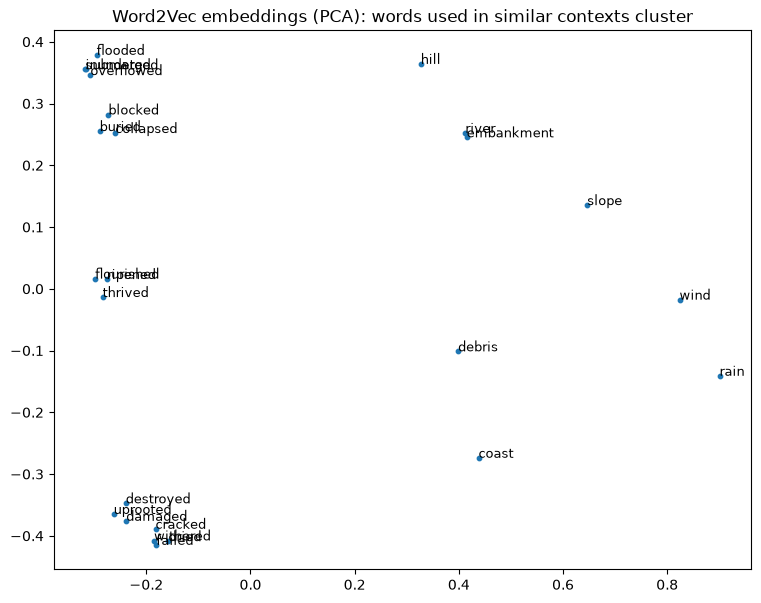

In [8]:
from sklearn.decomposition import PCA
show = ["flooded", "submerged", "inundated", "overflowed", "dried", "withered", "cracked", "failed", "damaged", "uprooted", "destroyed",
        "blocked", "buried", "collapsed", "flourished", "thrived", "ripened", "river", "embankment", "slope", "hill", "coast", "wind", "rain", "debris"]
show = [w for w in show if w in stoi]
P2 = PCA(2).fit_transform(E[[stoi[w] for w in show]].numpy())
plt.figure(figsize=(9, 7)); plt.scatter(*P2.T, s=10)
for (a, b), w in zip(P2, show): plt.annotate(w, (a, b), fontsize=9)
plt.title("Word2Vec embeddings (PCA): words used in similar contexts cluster"); plt.show()

## **6. Document Embeddings and Semantic Search**
Average the word vectors of a document (simple but effective), then search by **cosine similarity**. A query can find relevant reports even if it shares **no exact words** with them.

In [9]:
def doc_vec(text):
    ids = [stoi[t] for t in tokenize(text) if t in stoi]
    return F.normalize(E[ids].mean(0), dim=0) if ids else torch.zeros(E.shape[1])
D = torch.stack([doc_vec(d) for d in docs])
for query in ["water submerged the embankment", "slope collapsed with mud"]:
    top = (D @ doc_vec(query)).argsort(descending=True)[:3]
    print(f"query: '{query}'"); [print(f"   {docs[i]}  [{labels[y[i]]}]") for i in top]

X_emb_tr = torch.stack([doc_vec(d) for d in d_tr]).numpy(); X_emb_te = torch.stack([doc_vec(d) for d in d_te]).numpy()
print("logistic regression on averaged word2vec (32-D):", round(LogisticRegression(max_iter=3000).fit(X_emb_tr, y_tr).score(X_emb_te, y_te), 3))

query: 'water submerged the embankment'
   the rice field submerged in Puri after water level rose officials said the embankment inundated.  [flood]
   the river flooded in Kutch after water level rose officials said the rice field inundated.  [flood]
   the rice field overflowed in Ranchi after water level rose officials said the river submerged.  [flood]
query: 'slope collapsed with mud'
   the slope buried in Nadia after steep slope and steep slope.  [landslide]
   the hill road collapsed in Midnapore after steep slope and steep slope.  [landslide]
   the hill road collapsed in Dhanbad after steep slope and steep slope.  [landslide]
logistic regression on averaged word2vec (32-D): 1.0


# **Part 2: Going Deeper - Limits of Static Embeddings**

Word2Vec gives **one vector per word type**. But "bank" (river bank vs money bank), "plant" (factory vs vegetation) and "crane" (bird vs machine) have different meanings in different contexts. **Contextual** embeddings (ELMo, BERT, GPT; Day 69) produce a different vector for each **occurrence**, computed from the whole sentence by a Transformer. They also capture word order, negation ("no rain" vs "rain") and long-range dependencies that averaging cannot.

In [10]:
neg_test = ["the crop failed after no rain.", "the crop flourished after good rain."]
print("cosine similarity of averaged embeddings for opposite meanings:", round((doc_vec(neg_test[0]) @ doc_vec(neg_test[1])).item(), 3))

cosine similarity of averaged embeddings for opposite meanings: 0.964


## **Practice Problems**
1. Use character n-grams (`TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))`). How robust is it to typos (e.g. "fluded")?
2. Train skip-gram with window 1 and window 5. How do the nearest neighbours of "flooded" change?
3. Weight word vectors by their TF-IDF when averaging document embeddings. Does classification improve?
4. *(Advanced)* Implement an analogy query $\mathbf v_{b} - \mathbf v_{a} + \mathbf v_{c}$ (e.g. flooded - river + slope) and list the nearest words.

In [11]:
# Solution 1
char_clf = make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4)), LogisticRegression(max_iter=2000)).fit(d_tr, y_tr)
typo = ["the rivr fluded the vilage after hevy rain."]
print("char n-gram model on a typo-ridden flood report:", labels[char_clf.predict(typo)[0]], "| word model:", labels[tfidf_clf.predict(typo)[0]])
# Solution 3
tf = TfidfVectorizer(token_pattern=r"[a-z]+").fit(d_tr); tf_vocab = tf.vocabulary_
def tfidf_doc_vec(text):
    row = tf.transform([text]); ids, ws = [], []
    for t in set(tokenize(text)):
        if t in stoi and t in tf_vocab: ids.append(stoi[t]); ws.append(row[0, tf_vocab[t]])
    return (torch.tensor(ws, dtype=torch.float32)[:, None] * E[ids]).sum(0).numpy() if ids else np.zeros(E.shape[1])
print("TF-IDF-weighted embeddings:", round(LogisticRegression(max_iter=3000).fit(np.stack([tfidf_doc_vec(d) for d in d_tr]), y_tr).score(np.stack([tfidf_doc_vec(d) for d in d_te]), y_te), 3))
# Solution 4
def analogy(a, b, c, k=5):
    v = F.normalize(E[stoi[b]] - E[stoi[a]] + E[stoi[c]], dim=0); sims = E @ v
    return [itos[i] for i in sims.argsort(descending=True)[:k + 3].tolist() if itos[i] not in (a, b, c)][:k]
print("flooded - river + slope ->", analogy("river", "flooded", "slope"))

char n-gram model on a typo-ridden flood report:

 flood | word model: drought


TF-IDF-weighted embeddings: 1.0
flooded - river + slope -> ['overflowed', 'inundated', 'submerged', 'hill', 'blocked']


## **Key References**
- Salton, G., & Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. *Information Processing & Management*, 24(5), 513-523.
- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. *NeurIPS 26*.
- Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global vectors for word representation. *EMNLP 2014*.
- Sennrich, R., Haddow, B., & Birch, A. (2016). Neural machine translation of rare words with subword units. *ACL 2016* (BPE).
- Jurafsky, D., & Martin, J. H. (2024). *Speech and Language Processing* (3rd ed. draft). web.stanford.edu/~jurafsky/slp3.